In [1]:
%load_ext autoreload
%autoreload 2

In [30]:
from ariel_pred.dataset import DataLoaderAndCalibrator
from ariel_pred.preprocessing import SGSmoothing
from ariel_pred.plots import plot_white_curve
from ariel_pred.transit import FunctionFittingBasedPhaseDetector
from ariel_pred.models import TransitMultiplicationFactorFinder, SValuesCNN, SValuesCNNTrainer
from ariel_pred.features import WavelengthsGroupsMultiplierFinder
from ariel_pred.metrics import score, gll
from ariel_pred.sigma import OGSignalVarBasedSigmaCalculator
from ariel_pred.modeling.s_values_cnn_with_star_info import SValuesCNNWithStarInfoModel, SValuesCNNWithStarInfoTrainer
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import random
from scipy.optimize import minimize
from tqdm.auto import tqdm
import pandas as pd
import torch
from torch import nn
import scipy

In [3]:
data_loader = DataLoaderAndCalibrator(
    data_path=Path("../data/raw"),
    output_path=Path("../data/calibrated/full"),
    force_recalibration=False,
    cut_airs_channels=True,
    binning=4,
    n_jobs=4
)
train_data, train_labels = data_loader.load_all_train_data()
train_data.shape, train_labels.shape

Loading calibrated train data...


((1100, 1406, 283), (1100, 283))

In [4]:
features_extractor = WavelengthsGroupsMultiplierFinder()

features = features_extractor.extract_features(
    train_data,
    average_cross_groups=False,
    wavelengths_groups=[1, 2, 4, 8, 16, 32, 64],
    weights=[1, 1, 1, 1, 1, 1, 1]
)

features.shape

  0%|          | 0/1100 [00:00<?, ?it/s]

(1100, 283, 7)

In [5]:
model_data = features.transpose(0, 2,1)
model_data.shape

(1100, 7, 283)

In [6]:
star_info_df = pd.read_csv("../data/raw/train_star_info.csv")
star_info_df.head()

,planet_id,Rs,Ms,Ts,Mp,e,P,sma,i
0,34983,1.155435,1.062961,5577.006645,0.694946,0.0,3.305589,8.550786,89.150759
1,1873185,1.813230,1.370451,6216.229756,0.610845,0.0,6.352660,9.553384,88.701514
2,3849793,0.653807,0.667352,4968.477186,1.529200,0.0,5.522798,15.285661,89.134177
3,8456603,1.250623,1.162019,6023.702622,2.262107,0.0,7.541019,14.144310,87.178007
4,23615382,1.431492,1.306489,6128.061013,0.861299,0.0,4.368080,8.347654,90.000000


In [7]:
star_info = star_info_df[["Rs", "i"]].values
star_info.shape

(1100, 2)

In [23]:
trainer = SValuesCNNWithStarInfoTrainer(
    Path("../models/s_values_cnn_with_star_info"),
    n_splits=5,
    num_channels=model_data.shape[1],
    wavelengths=model_data.shape[2],
    num_star_features=star_info.shape[1]
)
val_losses, train_losses, val_preds_list = trainer.train(model_data*1e3, star_info, train_labels*1e3, epochs=300)

Fold 1/5


Training:   0%|          | 0/300 [00:00<?, ?it/s]

Loading weights from ../models/s_values_cnn_with_star_info/model_fold_1.pt
Fold 2/5


Training:   0%|          | 0/300 [00:00<?, ?it/s]

Loading weights from ../models/s_values_cnn_with_star_info/model_fold_2.pt
Fold 3/5


...

Loading weights from ../models/s_values_cnn_with_star_info/model_fold_3.pt
Fold 4/5


Training:   0%|          | 0/300 [00:00<?, ?it/s]

Loading weights from ../models/s_values_cnn_with_star_info/model_fold_4.pt
Fold 5/5


Training:   0%|          | 0/300 [00:00<?, ?it/s]

Loading weights from ../models/s_values_cnn_with_star_info/model_fold_5.pt


In [26]:
val_preds_list.shape, train_labels.shape

((1100, 283), (1100, 283))

In [29]:
predections = val_preds_list / 1e3
np.sqrt(np.mean((predections - train_labels)**2))

np.float64(0.0006567322787709568)

In [31]:
np.sqrt(np.mean((predections[:, 0] - train_labels[:, 0])**2))

np.float64(0.0008822060008526896)

In [45]:
spectrum = predections
sigma_calculator = OGSignalVarBasedSigmaCalculator(
    mean_fgs_sigma = 9.0e-4,
    mean_airs_sigma = 6.5e-4,
    fgs_min_sigma = 1e-6,
    airs_min_sigma = 1e-6,
)
sigma = sigma_calculator.get_sigma(train_data)
gll(np.concatenate([spectrum, sigma], axis=1), train_labels)

  0%|          | 0/1100 [00:00<?, ?it/s]

Calculating FGS sigma:   0%|          | 0/1100 [00:00<?, ?it/s]

Calculating AIRS sigma:   0%|          | 0/1100 [00:00<?, ?it/s]

0.3910564187841781

In [37]:
train_data.shape

(1100, 1406, 283)

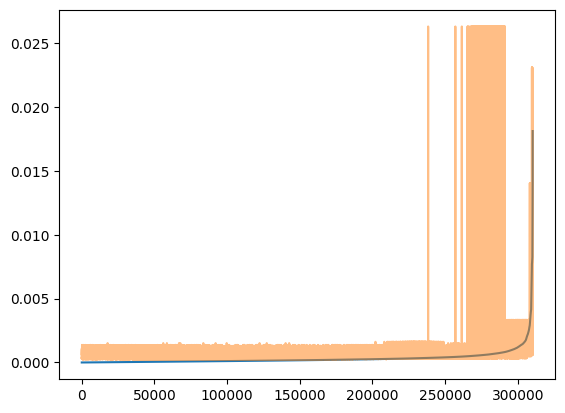

In [52]:
airs_errors = np.abs(predections[:, 1:] - train_labels[:, 1:]).flatten()
airs_flat_sigma = sigma[:, 1:].flatten()
plt.plot(np.sort(airs_errors))
plt.plot(airs_flat_sigma[np.argsort(airs_errors)], alpha=0.5)
plt.show()